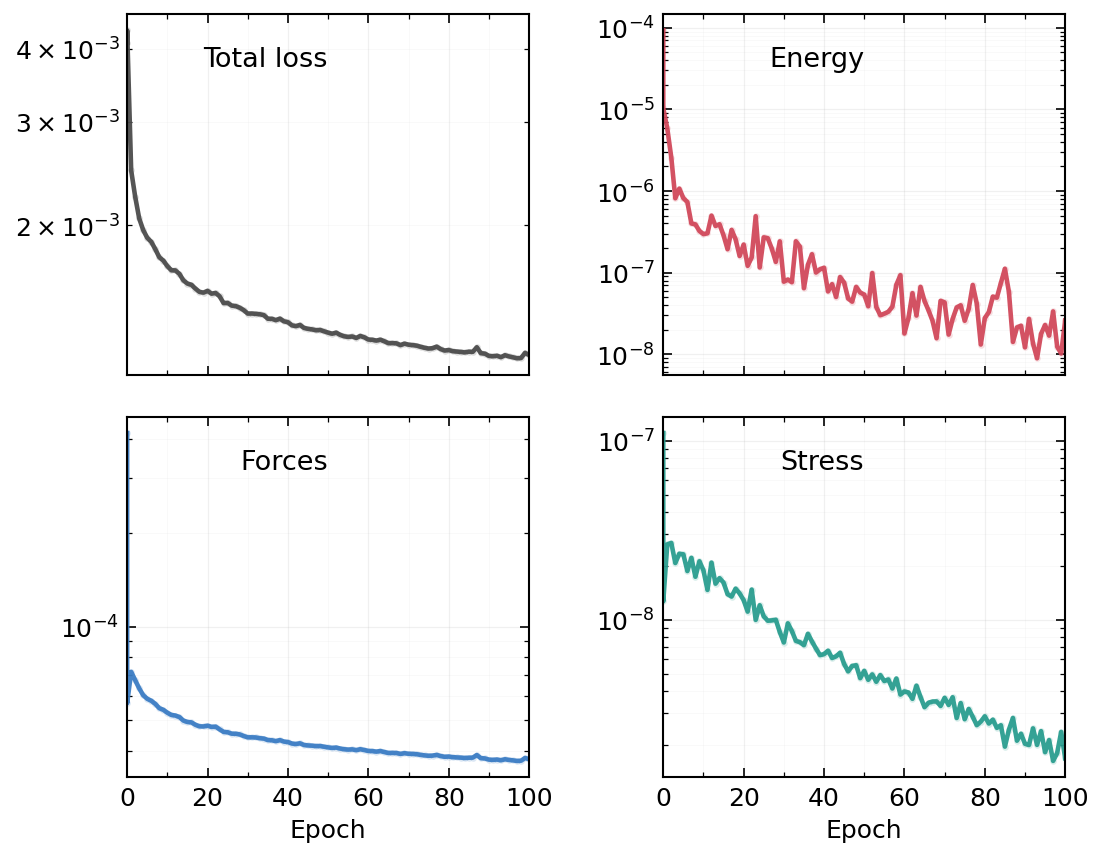

In [11]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ----------------------------
# Panel colors
# ----------------------------
PANEL_COLORS = {
    "total":  "#4c4c4c",
    "energy": "#D1495B",
    "forces": "#3C7DC4",
    "stress": "#2A9D8F",
}

SPLIT_STYLES = {
    "train": dict(linestyle="-",  alpha=0.95),
    "valid": dict(linestyle="--", alpha=0.90),
    "test":  dict(linestyle=":",  alpha=0.90),
}

# ----------------------------
# Style
# ----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
})

def _load_yaml(yaml_file):
    p = Path(yaml_file)
    if not p.exists():
        raise FileNotFoundError(f"{yaml_file} not found")
    with open(p) as f:
        data = yaml.safe_load(f)
    return data

def _series(data, key):
    return np.asarray([d.get(key, np.nan) for d in data], float)

def _plot_metric(ax, epochs, data, base_key, title, color, x_max=100):
    splits = [s for s in ("train", "valid", "test")
              if any(f"{base_key}/{s}" in d for d in data)]

    for split in splits:
        y = _series(data, f"{base_key}/{split}")
        m = np.isfinite(epochs) & np.isfinite(y) & (epochs <= x_max) & (y > 0)

        ax.plot(
            epochs[m], y[m],
            color=color,
            lw=2.2,
            label=split,
            **SPLIT_STYLES[split]
        )
        ax.scatter(
            epochs[m], y[m],
            s=10, color=color, alpha=0.18,
            linewidths=0, rasterized=True
        )

    ax.set_yscale("log")
    ax.set_xlim(0, x_max)

    ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

    ax.grid(True, which="major", linewidth=0.6, alpha=0.18)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.08)

    # Title safely inside panel (no line above it)
    ax.text(
        0.5, 0.91, title,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=13
    )

    ax.tick_params(axis="both", which="major", pad=4)

    return splits  # return splits so we know later whether to show legend

def plot_mace_like(yaml_file="train_metrics.yaml", x_max=100):
    data = _load_yaml(yaml_file)
    epochs = np.asarray([d["epoch"] for d in data], float)

    fig, axs = plt.subplots(
        2, 2,
        figsize=(7.2, 5.6),
        sharex=True,
        constrained_layout=True
    )

    fig.set_constrained_layout_pads(
        w_pad=0.02, h_pad=0.04,
        wspace=0.08, hspace=0.10
    )

    splits_all = []
    splits_all += _plot_metric(axs[0, 0], epochs, data, "total_loss",            "Total loss", PANEL_COLORS["total"],  x_max)
    splits_all += _plot_metric(axs[0, 1], epochs, data, "loss_component/energy", "Energy",     PANEL_COLORS["energy"], x_max)
    splits_all += _plot_metric(axs[1, 0], epochs, data, "loss_component/forces", "Forces",     PANEL_COLORS["forces"], x_max)
    splits_all += _plot_metric(axs[1, 1], epochs, data, "loss_component/stress", "Stress",     PANEL_COLORS["stress"], x_max)

    # X labels only bottom row
    for ax in axs[1, :]:
        ax.set_xlabel("Epoch")

    # Remove y labels completely
    for ax in axs[:, 0]:
        ax.set_ylabel("")

    # X ticks
    for ax in axs[1, :]:
        ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(10))

    # ✅ ONLY show legend if more than one split exists
    unique_splits = sorted(set(splits_all))
    if len(unique_splits) > 1:
        handles, labels = axs[0, 0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc="upper center",
            ncol=len(unique_splits),
            bbox_to_anchor=(0.5, 1.05),
            handlelength=2.0,
            columnspacing=1.5
        )

    # Ensure no axis-level legends remain
    for ax in axs.flat:
        if ax.legend_:
            ax.legend_.remove()

    fig.savefig("finetuning_metrics.pdf", bbox_inches="tight")
    fig.savefig("finetuning_metrics.png", bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    plot_mace_like()
